<a href="https://colab.research.google.com/github/thomazcabral/projetos-if702/blob/main/Equipe_2_Miniprojeto_LSTM_bitcoins.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [23]:
pip install optuna -q

In [24]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.model_selection import TimeSeriesSplit
import optuna
import warnings

# Supressão de warnings de depreciação de bibliotecas base para uma saída limpa
warnings.filterwarnings("ignore")


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"-> Computação acelerada operando em: {device.type.upper()}")

-> Computação acelerada operando em: CUDA


In [25]:
# =============================================================================
# 1. ENGENHARIA MULTIVARIADA DE ATRIBUTOS (FEATURE ENGINEERING)
# =============================================================================

def calculate_technical_indicators(df):
    df_feat = df.copy()

    df_feat['EMA_9'] = df_feat['close'].ewm(span=9, adjust=False).mean()
    df_feat['EMA_21'] = df_feat['close'].ewm(span=21, adjust=False).mean()

    # RSI
    delta = df_feat['close'].diff()
    gain = (delta.where(delta > 0, 0)).rolling(window=14).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean()
    rs = gain / loss
    df_feat['RSI'] = 100 - (100 / (1 + rs))

    # MACD
    ema_12 = df_feat['close'].ewm(span=12, adjust=False).mean()
    ema_26 = df_feat['close'].ewm(span=26, adjust=False).mean()
    df_feat['MACD'] = ema_12 - ema_26
    df_feat['Signal_Line'] = df_feat['MACD'].ewm(span=9, adjust=False).mean()

    # Bollinger Bands
    df_feat['BB_mid'] = df_feat['close'].rolling(window=20).mean()
    std_20 = df_feat['close'].rolling(window=20).std()
    df_feat['BB_upper'] = df_feat['BB_mid'] + (std_20 * 2)
    df_feat['BB_lower'] = df_feat['BB_mid'] - (std_20 * 2)

    df_feat.dropna(inplace=True)
    return df_feat

def load_and_preprocess_data(filepath, seq_length=14):
    """
    Realiza o carregamento do dataset, delimitação de período (2017-2023),
    divisão de conjunto e escalonamento rigoroso para prevenir vazamento de dados.
    Utiliza RobustScaler para evitar o esmagamento de tensores provocado por outliers.
    """
    df = pd.read_csv(filepath, parse_dates=['date'])
    df.set_index('date', inplace=True)
    df = df.sort_index()

    # Restrição das datas ao escopo exato estipulado no projeto
    df = df.loc['2017-01-01':'2023-12-31']

    # Aplicação do construtor de features matemáticas multivariadas
    df = calculate_technical_indicators(df)

    # Remova o 'date' e adicione os indicadores matemáticos que foram criados
    feature_cols = ['open', 'high', 'low', 'close', 'number_of_trades',
                    'EMA_9', 'EMA_21', 'RSI', 'MACD', 'Signal_Line',
                    'BB_mid', 'BB_upper', 'BB_lower']
    target_col = 'close'

    data = df[feature_cols].values
    target = df[[target_col]].values

    # Divisão Cronológica Sequencial Exata: (80% Treino, 20% Teste)
    # Não há random state misturando ordens temporais para preservar o fator autoregressivo
    train_size = int(len(data) * 0.8)

    train_data = data[:train_size]
    test_data = data[train_size:]

    train_target = target[:train_size]
    test_target = target[train_size:]

    # Instanciação de escalonadores baseados na amplitude interquartil
    feature_scaler = RobustScaler()
    target_scaler = RobustScaler()

    # Fit transform aplicado única e exclusivamente sobre o treino de dados
    train_data_scaled = feature_scaler.fit_transform(train_data)
    test_data_scaled = feature_scaler.transform(test_data)

    train_target_scaled = target_scaler.fit_transform(train_target)
    test_target_scaled = target_scaler.transform(test_target)

    def create_sequences(X, y, seq_length):
        """
        Gerador deslizante de janelas estruturado metodologicamente para extirpar look-ahead bias.
        O modelo deve basear-se puramente em (t-L) até (t-1) para produzir as estimativas do instante (t).
        """
        xs, ys = [], []
        for i in range(len(X) - seq_length):
            xs.append(X[i:(i + seq_length)])
            ys.append(y[i + seq_length])
        return np.array(xs), np.array(ys)

    X_train, y_train = create_sequences(train_data_scaled, train_target_scaled, seq_length)
    X_test, y_test = create_sequences(test_data_scaled, test_target_scaled, seq_length)

    return X_train, y_train, X_test, y_test, target_scaler

In [26]:
# =============================================================================
# 2. DEFINIÇÃO ORIENTADA A OBJETOS DOS CARREGADORES E MÉTRICAS
# =============================================================================

class BitcoinSequenceDataset(Dataset):
    """ Classe PyTorch abstrata mapeando tensores com a estrutura do Dataset """
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

def calculate_pocid(y_true, y_pred):
    """
    Prediction of Change in Direction (POCID)
    Monitoramento direcional das inflexões de mercado em percentual.
    Mede a acurácia se as flutuações das predições de mercado t - t_anterior
    refletem corretamente as mudanças da vida real na cotação temporal.
    """
    y_true = np.array(y_true).flatten()
    y_pred = np.array(y_pred).flatten()

    # Subtrações vetoriais calculando diferenças em série temporal
    D_true = np.diff(y_true)
    D_pred = y_pred[1:] - y_true[:-1]

    # Conformidade direcional onde os sinais (+ ou -) vetoriais concordam
    correct_directions = np.sum((D_true * D_pred) > 0)
    total_transitions = len(D_true)

    pocid_score = (correct_directions / total_transitions) * 100.0 if total_transitions > 0 else 0
    return pocid_score


In [27]:
# =============================================================================
# 3. ARQUITETURA MODULAR RECORRENTE
# =============================================================================

class AdvancedForecastingNetwork(nn.Module):
    """
    Estrutura adaptativa permitindo otimização de matrizes. Rege os parâmetros
    em arquitetura modular similar a implementações base de Convolutional Neural Networks
    enquanto emprega os portões intrínsecos de LSTM em empilhamento de camadas.
    """
    def __init__(self, input_dim, hidden_dim, num_layers, dropout_rate):
        super(AdvancedForecastingNetwork, self).__init__()
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers

        # Camada recorrente processando a dependência do estado a longo e curto prazo
        self.lstm = nn.LSTM(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            # Dropout inserido inter-camadas caso seja uma arquitetura mais profunda (stacked)
            dropout=dropout_rate if num_layers > 1 else 0.0
        )

        # Módulos de filtragem de sinal contra memorização dos pesos
        self.dropout = nn.Dropout(dropout_rate)
        # Cabeça densa de aproximação regressiva com afunilamento geométrico
        self.fc1 = nn.Linear(hidden_dim, hidden_dim // 2)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_dim // 2, 1)

    def forward(self, x):
        # A inicialização zero padronizada do hidden e cell state em PyTorch (h_0, c_0)
        lstm_out, _ = self.lstm(x)

        # O fatiamento captura especificamente a representação encapsulada do
        # último passo dimensional gerado dentro do fluxo multivariado da sequência da matriz
        out = lstm_out[:, -1, :]

        out = self.dropout(out)
        out = self.relu(self.fc1(out))
        out = self.fc2(out)
        return out


In [28]:

# =============================================================================
# 4. LOOP DE TREINAMENTO E OTIMIZAÇÃO BAYESIANA COM OPTUNA (TPE)
# =============================================================================

def execute_model_training_cycle(params, X_train, y_train, X_test, y_test, target_scaler, device):
    """
    Roda um epoch lifecycle unificado com Early Stopping lógico. Retorna as validações
    necessárias para a função de custo minimizadora do framework Optuna.
    """
    train_dataset = BitcoinSequenceDataset(X_train, y_train)
    test_dataset = BitcoinSequenceDataset(X_test, y_test)

    train_loader = DataLoader(train_dataset, batch_size=params['batch_size'], shuffle=False)
    test_loader = DataLoader(test_dataset, batch_size=params['batch_size'], shuffle=False)

    # Inicia e envia o grafo computacional para memória GPU / CPU
    model = AdvancedForecastingNetwork(
        input_dim=X_train.shape[2],
        hidden_dim=params['hidden_dim'],
        num_layers=params['num_layers'],
        dropout_rate=params['dropout']
    ).to(device)

    # Huber Loss atua linear e quadraticamente estabilizando gradientes anômalos de cotação
    criterion = nn.HuberLoss()
    # Otimizador com suporte ao controle de decaimento de regularização L2 estrito
    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=params['lr'],
        weight_decay=params['weight_decay']
    )

    epochs = 40  # Escala balanceada entre busca de convergência e restrição de tempo da modelagem

    for epoch in range(epochs):
        model.train()
        for batch_X, batch_y in train_loader:
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)

            optimizer.zero_grad()
            outputs = model(batch_X)
            loss = criterion(outputs, batch_y)
            loss.backward()
            optimizer.step()

    # Estado de avaliação final de passagem cruzada (Cross validation testing pass)
    model.eval()
    val_loss = 0.0
    all_preds = []
    all_trues = []

    with torch.no_grad():
        for batch_X, batch_y in test_loader:
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)
            outputs = model(batch_X)

            # Acumulando loss pela formula de amostragem proporcional
            loss = criterion(outputs, batch_y)
            val_loss += loss.item() * batch_X.size(0)

            all_preds.extend(outputs.cpu().numpy())
            all_trues.extend(batch_y.cpu().numpy())

    val_loss /= len(test_loader.dataset)

    # Transformação de valores revertendo o formato normalizado para análise humana e POCID
    preds_inverse = target_scaler.inverse_transform(all_preds)
    trues_inverse = target_scaler.inverse_transform(all_trues)

    pocid = calculate_pocid(trues_inverse, preds_inverse)
    rmse = np.sqrt(mean_squared_error(trues_inverse, preds_inverse))

    return val_loss, rmse, pocid, model, preds_inverse, trues_inverse

def optuna_objective(trial):
    """
    Espaço de busca expandido para explorar novas dinâmicas temporais,
    mantendo a validação cruzada para garantir a confiabilidade do POCID.
    """
    # Adicionadas janelas de 10 dias e 30 dias (1 mês comercial)
    seq_length = trial.suggest_categorical('seq_length', [7, 10, 14, 21, 30])

    params = {
        # Aumentamos o teto para 160 neurônios, permitindo um "cérebro" levemente maior
        'hidden_dim': trial.suggest_int('hidden_dim', 32, 256, step=32),

        # Permitindo até 3 camadas para capturar padrões hierárquicos mais difíceis
        'num_layers': trial.suggest_int('num_layers', 1, 10),

        # Espectro de dropout mais amplo (20% a 65% de esquecimento)
        'dropout': trial.suggest_float('dropout', 0.2, 0.65),

        # Taxa de aprendizado com margem para passos mais curtos (5e-5) ou mais longos (5e-3)
        'lr': trial.suggest_float('lr', 5e-5, 5e-3, log=True),

        # Weight decay com punições flexíveis (L2 Regularization)
        'weight_decay': trial.suggest_float('weight_decay', 1e-6, 1e-2, log=True),

        # Retornando o 64 para ver se lotes médios estabilizam o gradiente melhor que 16
        'batch_size': trial.suggest_categorical('batch_size', [16, 32, 64])


    }

    # Carrega os dados inteiros (bloco de treino de 80%)
    X_train_full, y_train_full, _, _, target_scaler = load_and_preprocess_data(
        'data-bitcoin_timedata-2023_v2.csv',
        seq_length=seq_length
    )

    # Walk-Forward Validation (Testando em 3 momentos diferentes do tempo)
    tscv = TimeSeriesSplit(n_splits=3)
    cv_losses = []

    for train_index, val_index in tscv.split(X_train_full):
        X_fold_train, X_fold_val = X_train_full[train_index], X_train_full[val_index]
        y_fold_train, y_fold_val = y_train_full[train_index], y_train_full[val_index]

        # Executa o ciclo de treino neste fold
        fold_loss, _, _, _, _, _ = execute_model_training_cycle(
            params, X_fold_train, y_fold_train, X_fold_val, y_fold_val, target_scaler, device
        )
        cv_losses.append(fold_loss)

    # Optuna tentará minimizar a média de erro cruzado
    return np.mean(cv_losses)

[I 2026-04-24 23:24:55,131] A new study created in memory with name: no-name-7b193def-1187-4a47-a2eb-c77fd100d071


 Inicializando Otimização Bayesiana Estruturada do Espaço LSTM em Pytorch...


[I 2026-04-24 23:25:15,113] Trial 0 finished with value: 0.041568995088984755 and parameters: {'seq_length': 10, 'hidden_dim': 64, 'num_layers': 3, 'dropout': 0.5897792655987208, 'lr': 0.0007965261308120511, 'weight_decay': 0.0006796578090758161, 'batch_size': 32}. Best is trial 0 with value: 0.041568995088984755.
[I 2026-04-24 23:25:42,815] Trial 1 finished with value: 0.3014078651691526 and parameters: {'seq_length': 30, 'hidden_dim': 128, 'num_layers': 15, 'dropout': 0.4753338026250708, 'lr': 9.505122659935192e-05, 'weight_decay': 1.4742753159914662e-05, 'batch_size': 64}. Best is trial 0 with value: 0.041568995088984755.
[I 2026-04-24 23:25:53,657] Trial 2 finished with value: 0.05724492960678781 and parameters: {'seq_length': 30, 'hidden_dim': 64, 'num_layers': 4, 'dropout': 0.6269984917639999, 'lr': 0.004268094931433415, 'weight_decay': 0.0017123375973163992, 'batch_size': 64}. Best is trial 0 with value: 0.041568995088984755.
[I 2026-04-24 23:27:01,832] Trial 3 finished with val



-> Mínimo Custo (Val Loss): 0.04157
-> Combinação Topológica Vencedora Encontrada:
   * seq_length: 7
   * hidden_dim: 64
   * num_layers: 3
   * dropout: 0.34639864884346894
   * lr: 0.00029945018361271497
   * weight_decay: 1.2172958098369984e-05
   * batch_size: 16


-> Computação acelerada operando em: CUDA


-> Root Mean Squared Error (RMSE) Absoluto: $2924.36
-> Métrica Qualitativa Financeira (POCID): 49.06% de Correção Direcional (Tendência)


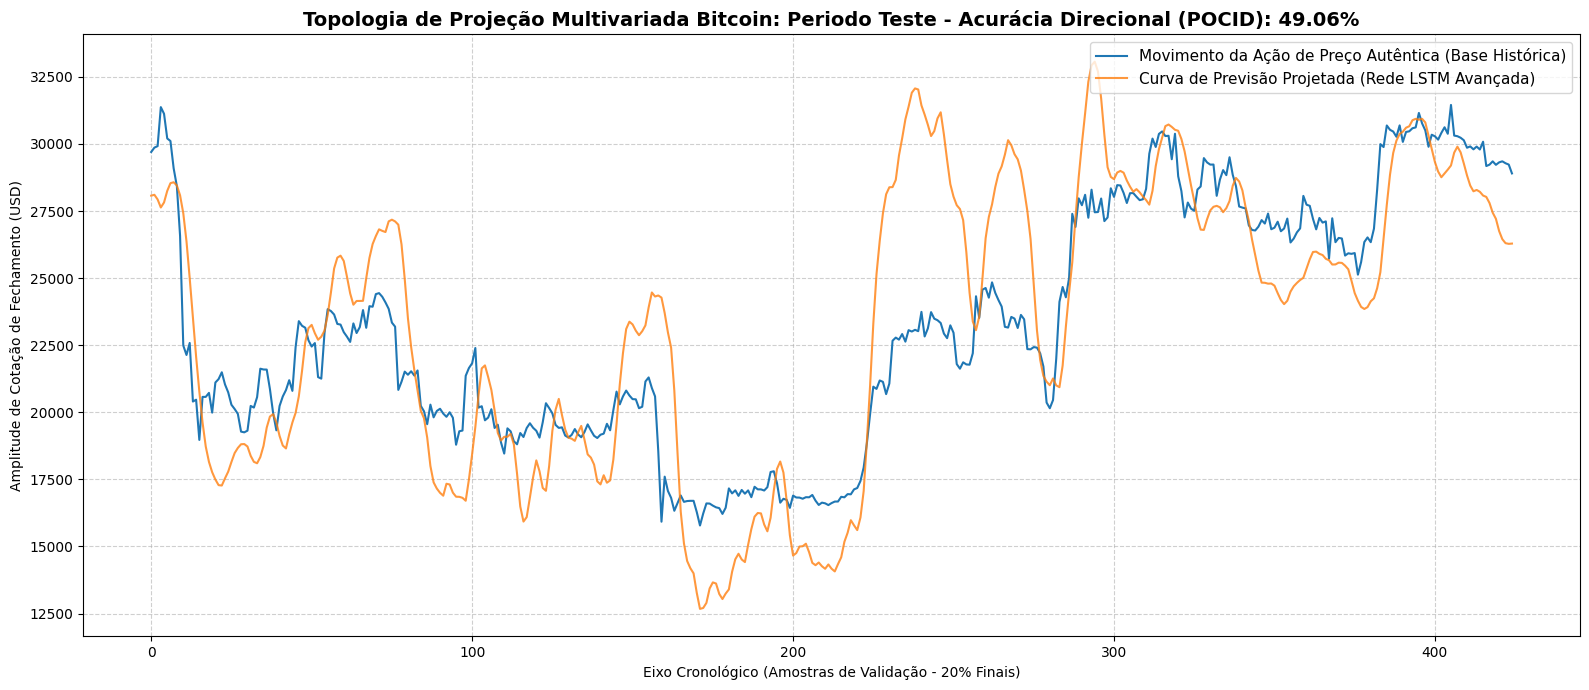

[FIM] Ciclo de otimização algorítmica finalizado com segurança metodológica.


In [29]:
# =============================================================================
# 5. BLOCO DE CONTROLE CENTRAL (SCRIPT MAIN)
# =============================================================================
if __name__ == "__main__":
    print(" Inicializando Otimização Bayesiana Estruturada do Espaço LSTM em Pytorch...")

    # Instância do Tracker de otimização minimizadora TPE Sampling do Optuna
    study = optuna.create_study(direction='minimize', sampler=optuna.samplers.TPESampler(seed=42))

    # Numero de execuções para convergência da pesquisa paramétrica.
    study.optimize(optuna_objective, n_trials=10)

    print("\n")
    print(f"-> Mínimo Custo (Val Loss): {study.best_value:.5f}")
    print("-> Combinação Topológica Vencedora Encontrada:")

    best_params = study.best_params
    for key, value in best_params.items():
        print(f"   * {key}: {value}")

    print("\n")

    best_seq_length = best_params.pop('seq_length')
    X_train, y_train, X_test, y_test, target_scaler = load_and_preprocess_data(
        'data-bitcoin_timedata-2023_v2.csv',
        seq_length=best_seq_length
    )

    final_loss, final_rmse, final_pocid, final_model, preds, trues = execute_model_training_cycle(
        best_params, X_train, y_train, X_test, y_test, target_scaler, device
    )

    print("\n")
    print(f"-> Root Mean Squared Error (RMSE) Absoluto: ${final_rmse:.2f}")
    print(f"-> Métrica Qualitativa Financeira (POCID): {final_pocid:.2f}% de Correção Direcional (Tendência)")

    # Exposição Gráfica Qualitativa das Conclusões Modeladas
    plt.figure(figsize=(16, 7))
    plt.plot(trues, label='Movimento da Ação de Preço Autêntica (Base Histórica)', color='#1f77b4', linewidth=1.5)
    plt.plot(preds, label='Curva de Previsão Projetada (Rede LSTM Avançada)', color='#ff7f0e', alpha=0.8, linewidth=1.5)
    plt.title(f'Topologia de Projeção Multivariada Bitcoin: Periodo Teste - Acurácia Direcional (POCID): {final_pocid:.2f}%', fontsize=14, fontweight='bold')
    plt.xlabel('Eixo Cronológico (Amostras de Validação - 20% Finais)')
    plt.ylabel('Amplitude de Cotação de Fechamento (USD)')
    plt.legend(loc='upper right', frameon=True, fontsize=11)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()
    print("[FIM] Ciclo de otimização algorítmica finalizado com segurança metodológica.")

In [30]:
import optuna.visualization as vis

vis.plot_param_importances(study).show()

vis.plot_optimization_history(study).show()

vis.plot_parallel_coordinate(study).show()